In [9]:
import praw
import json
import time
from datetime import datetime, timezone

# 🔐 Reddit API credentials
reddit = praw.Reddit(
    client_id="MTncsak-AfThLgV2b-JrCQ",
    client_secret="dsXEHaHtzR3Y9aDiPHA06c_jtzH60w",
    user_agent="json_collector_v1"
)

def collect_100posts_10kcomments(subreddits, max_posts=100, max_comments_total=10000, max_comments_per_post=500):
    all_data = []
    post_count = 0
    comment_count = 0
    seen_post_ids = set()

    print(f"🔍 Collecting {max_posts} posts and up to {max_comments_total} comments...")

    for sub in subreddits:
        for post in reddit.subreddit(sub).hot(limit=2000):  # Go deep enough into hot posts
            if post.id in seen_post_ids or post.locked:
                continue
            seen_post_ids.add(post.id)

            post_time = datetime.fromtimestamp(post.created_utc, timezone.utc).strftime('%Y-%m-%d %H:%M:%S')

            # Save post
            all_data.append({
                "Type": "Post",
                "Post ID": post.id,
                "Title": post.title,
                "Post Text": post.selftext,
                "Subreddit": sub,
                "Created": post_time,
                "Score": post.score,
                "Comment": "",
                "URL": post.url
            })
            post_count += 1

            try:
                post.comments.replace_more(limit=0)
                for comment in post.comments.list()[:max_comments_per_post]:
                    if comment_count >= max_comments_total:
                        break

                    comment_time = datetime.fromtimestamp(comment.created_utc, timezone.utc).strftime('%Y-%m-%d %H:%M:%S')

                    all_data.append({
                        "Type": "Comment",
                        "Post ID": post.id,
                        "Title": post.title,
                        "Post Text": post.selftext,
                        "Subreddit": sub,
                        "Created": comment_time,
                        "Score": comment.score,
                        "Comment": comment.body,
                        "URL": post.url
                    })
                    comment_count += 1

            except Exception as e:
                print(f"⚠️ Error getting comments for post {post.id}: {e}")

            print(f"✅ Collected {post_count} posts | 💬 {comment_count} comments")

            if post_count >= max_posts and comment_count >= max_comments_total:
                break

            time.sleep(1.5)  # Respect API limits

        if post_count >= max_posts and comment_count >= max_comments_total:
            break

    print(f"\n🎯 Finished: {post_count} posts + {comment_count} comments = {len(all_data)} total rows")

    # Save to JSON
    with open("reddit_100posts_10kcomments.json", "w", encoding="utf-8") as f:
        json.dump(all_data, f, indent=2)

    print("📁 Saved as 'reddit_100posts_10kcomments.json'")

# ✅ List of relevant subreddits
subreddits = [
    "economy", "finance", "personalfinance",
    "CryptoCurrency", "StockMarket", "worldnews",
    "news", "politics"
]

# 🚀 Run the function
collect_100posts_10kcomments(subreddits)


🔍 Collecting 100 posts and up to 10000 comments...
✅ Collected 1 posts | 💬 162 comments
✅ Collected 2 posts | 💬 190 comments
✅ Collected 3 posts | 💬 235 comments
✅ Collected 4 posts | 💬 236 comments
✅ Collected 5 posts | 💬 243 comments
✅ Collected 6 posts | 💬 288 comments
✅ Collected 7 posts | 💬 301 comments
✅ Collected 8 posts | 💬 307 comments
✅ Collected 9 posts | 💬 370 comments
✅ Collected 10 posts | 💬 374 comments
✅ Collected 11 posts | 💬 379 comments
✅ Collected 12 posts | 💬 391 comments
✅ Collected 13 posts | 💬 406 comments
✅ Collected 14 posts | 💬 409 comments
✅ Collected 15 posts | 💬 429 comments
✅ Collected 16 posts | 💬 439 comments
✅ Collected 17 posts | 💬 468 comments
✅ Collected 18 posts | 💬 566 comments
✅ Collected 19 posts | 💬 680 comments
✅ Collected 20 posts | 💬 680 comments
✅ Collected 21 posts | 💬 681 comments
✅ Collected 22 posts | 💬 689 comments
✅ Collected 23 posts | 💬 689 comments
✅ Collected 24 posts | 💬 690 comments
✅ Collected 25 posts | 💬 710 comments
✅ Collec

In [73]:

from collections import defaultdict

# Load the original JSON
with open("reddit_100posts_10kcomments.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(f" Original entries: {len(data)}")

# Separate posts and comments
posts = [item for item in data if item["Type"] == "Post"]
comments_by_post = defaultdict(list)

for item in data:
    if item["Type"] == "Comment":
        comments_by_post[item["Post ID"]].append(item)

# Limit to 100 posts + ~30 comments per post
limited_data = []

for post in posts[:100]:  # Only 100 posts
    post_clean = {
        "Type": "Post",
        "Post ID": post["Post ID"],
        "Title": post.get("Title", ""),
        "Post Text": post.get("Post Text", ""),
        "Created": post.get("Created", "")
    }
    limited_data.append(post_clean)

    for comment in comments_by_post[post["Post ID"]][:30]:  # Up to 30 comments
        comment_clean = {
            "Type": "Comment",
            "Post ID": comment["Post ID"],
            "Comment": comment.get("Comment", ""),
            "Created": comment.get("Created", "")
        }
        limited_data.append(comment_clean)

print(f"Reduced dataset: {len(limited_data)} rows")

# Save as  JSON file
with open("reddit_inflation_100posts_sample.json", "w", encoding="utf-8") as f_out:
    json.dump(limited_data, f_out, indent=2)

print(" Saved: reddit_inflation_100posts_sample.json (check file size should be < 5MB)")


 Original entries: 10580
Reduced dataset: 980 rows
 Saved: reddit_inflation_100posts_sample.json (check file size should be < 5MB)


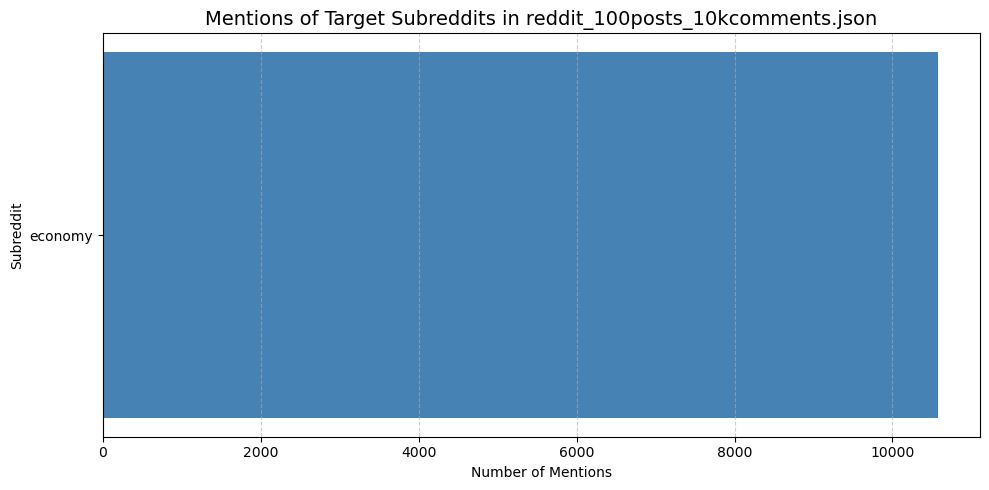

Top Matching Subreddits:
  Subreddit  Mentions
0   economy     10580


In [5]:
import json
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Subreddits of interest
target_subreddits = [
    "economy", "finance", "personalfinance",
    "CryptoCurrency", "StockMarket", "worldnews",
    "news", "politics"
]

# Load the JSON dataset
with open("reddit_100posts_10kcomments.json", "r", encoding="utf-8") as f:
    data = json.load(f)

#  Normalize subreddits (case-insensitive match)
filtered = [entry.get("Subreddit", "").lower() for entry in data if entry.get("Subreddit", "").lower() in [s.lower() for s in target_subreddits]]

# Count mentions
sub_counts = Counter(filtered)
df = pd.DataFrame(sub_counts.items(), columns=["Subreddit", "Mentions"]).sort_values(by="Mentions", ascending=False)

# 📈 Plot
plt.figure(figsize=(10, 5))
plt.barh(df["Subreddit"], df["Mentions"], color="steelblue")
plt.title("Mentions of Target Subreddits in reddit_100posts_10kcomments.json", fontsize=14)
plt.xlabel("Number of Mentions")
plt.ylabel("Subreddit")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 📋 Print summary
print("Top Matching Subreddits:")
print(df)


In [45]:
import json
import re
import string
from nltk.tokenize import TweetTokenizer
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
import nltk

# Download stopwords
nltk.download("stopwords")

# Setup tools
tokenizer = TweetTokenizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english")) | set(string.punctuation)

# 🧼 Define cleaning function
def clean_text(text):
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove URLs, handles, hashtags, digits, and non-ASCII
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[@#]\w+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\x00-\x7F]+", "", text)

    # Step 3: Tokenization
    tokens = tokenizer.tokenize(text)

    # Step 4: Strip and remove stopwords
    tokens = [t.strip() for t in tokens if t.strip()]
    tokens = [t for t in tokens if t not in stop_words]

    # Step 5: Stemming
    tokens = [stemmer.stem(t) for t in tokens]

    return " ".join(tokens)

# 📥 Load Reddit JSON
INPUT_FILE = "reddit_inflation_100posts_sample.json"
OUTPUT_FILE = "reddit_inflation_cleaned.json"

print(f"📥 Loading: {INPUT_FILE}")
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    reddit_data = json.load(f)

# 🔁 Process and clean
print("🧽 Cleaning text fields...")
for i, entry in enumerate(reddit_data):
    combined_text = " ".join([
        entry.get("Title", ""),
        entry.get("Post Text", ""),
        entry.get("Comment", "")
    ])
    entry["Cleaned Text"] = clean_text(combined_text)
    if (i + 1) % 100 == 0:
        print(f"✅ Processed {i + 1} entries")

# 💾 Save output
with open(OUTPUT_FILE, "w", encoding="utf-8") as f_out:
    json.dump(reddit_data, f_out, indent=2)

print(f"🎉 Done! Cleaned data saved to '{OUTPUT_FILE}'")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


📥 Loading: reddit_inflation_100posts_sample.json
🧽 Cleaning text fields...
✅ Processed 100 entries
✅ Processed 200 entries
✅ Processed 300 entries
✅ Processed 400 entries
✅ Processed 500 entries
✅ Processed 600 entries
✅ Processed 700 entries
✅ Processed 800 entries
✅ Processed 900 entries
🎉 Done! Cleaned data saved to 'reddit_inflation_cleaned.json'


In [49]:
import json
import re
from collections import Counter
from nltk.tokenize import TreebankWordTokenizer

# Load Reddit JSON data
with open("reddit_inflation_cleaned.json", "r", encoding="utf-8") as f:
    reddit_data = json.load(f)

# Combine all text (title + post text + comment)
all_text = " ".join([
    " ".join([
        entry.get("Title", ""),
        entry.get("Post Text", ""),
        entry.get("Comment", "")
    ]).lower() for entry in reddit_data
])

# Clean: remove URLs
all_text = re.sub(r"http\S+|www\S+", "", all_text)

# Tokenize and keep alphabetic words only
tokenizer = TreebankWordTokenizer()
tokens = tokenizer.tokenize(all_text)
tokens = [word for word in tokens if word.isalpha()]

# Count frequencies
word_freq = Counter(tokens)

# Get top 100 most frequent words
custom_stopwords = [word for word, _ in word_freq.most_common(100)]

# Save to a file
with open("custom_stopwords_from_reddit.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(custom_stopwords))

print("✅ Custom stopwords saved to 'custom_stopwords_from_reddit.txt'")


✅ Custom stopwords saved to 'custom_stopwords_from_reddit.txt'


In [167]:
!pip install textblob
import nltk
nltk.download('punkt')

from textblob import TextBlob


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ------------------------------- ------ 524.3/624.3 kB 365.1 kB/s eta 0:00:01
   -------------------------------------- 624.3/624.3 kB 386.5 kB/s eta 0:00:00


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


🔝 Top 10 most frequent terms in comments:
’: 340
trump: 151
us: 140
peopl: 122
tariff: 105
china: 104
like: 102
go: 90
year: 85
would: 82


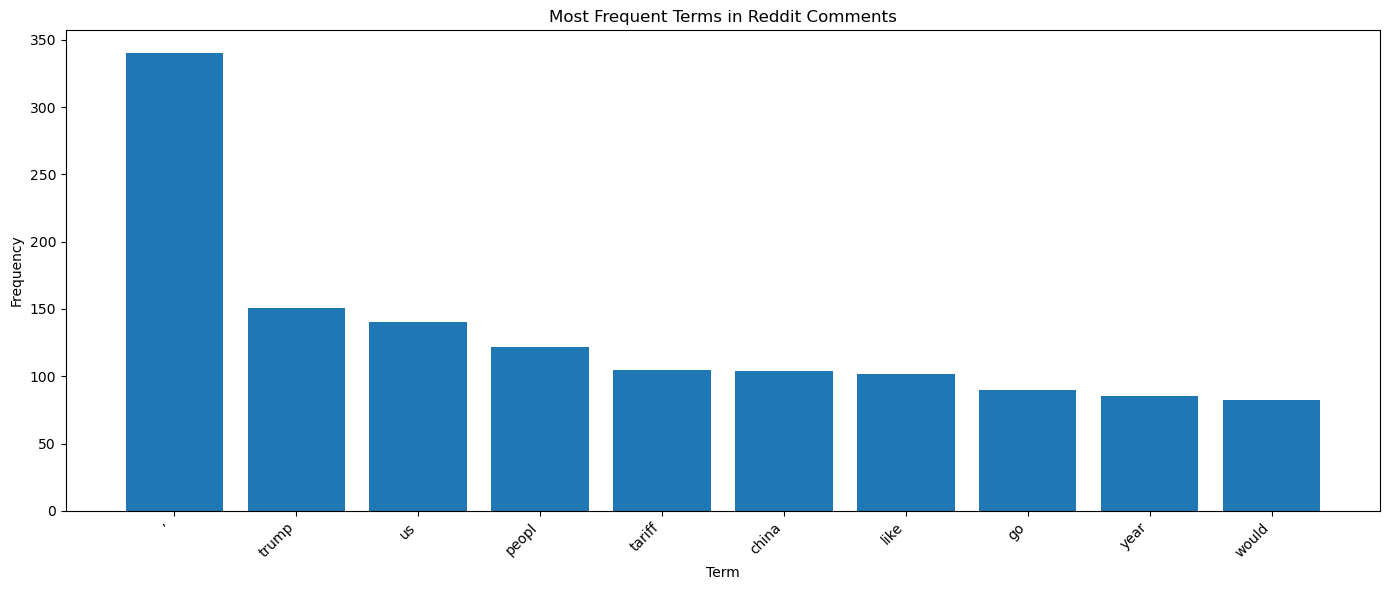

In [51]:
# load required libraries
import json
import re
import string
from collections import Counter
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import TweetTokenizer
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

# download required nltk data
nltk.download("stopwords")
nltk.download("punkt")

# set input file path
sInputFile = "reddit_inflation_cleaned.json"

# set number of terms to visualize
iTopTerms = 10

# define tokenizer, stemmer, and stopwords
tokenizer = TweetTokenizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english")) | set(string.punctuation) | {"rt", "via"}

# define text cleaning function
def processText(text, tokenizer, stemmer, stopwords):
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    return [stemmer.stem(t) for t in tokens if t not in stopwords and not t.isdigit()]

# initialize term frequency counter
termFreq = Counter()

# load json and process each comment
with open(sInputFile, "r", encoding="utf-8") as f:
    redditData = json.load(f)
    for entry in redditData:
        if entry.get("Type") == "Comment":
            comment = entry.get("Comment", "")
            cleanedTokens = processText(comment, tokenizer, stemmer, stop_words)
            termFreq.update(cleanedTokens)

# print top terms
print(f"🔝 Top {iTopTerms} most frequent terms in comments:")
for term, freq in termFreq.most_common(iTopTerms):
    print(f"{term}: {freq}")

# plot term frequencies
terms, counts = zip(*termFreq.most_common(iTopTerms))
plt.figure(figsize=(14, 6))
plt.bar(terms, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Most Frequent Terms in Reddit Comments")
plt.xlabel("Term")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


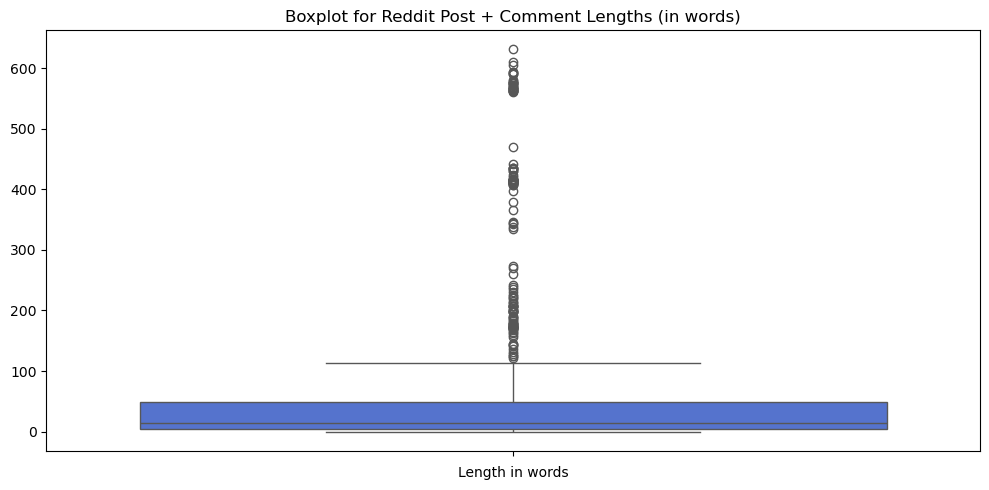

In [19]:
import json
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import pandas as pd
import re

# download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Load JSON data
with open("reddit_inflation_cleaned.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Clean & tokenize function
def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|[^a-zA-Z\s]", "", text)  # remove URLs and symbols
    tokens = word_tokenize(text, preserve_line=True)  # <== FIX HERE
    return [token for token in tokens if token not in stop_words and len(token) > 2]

#  Get all text and lengths
post_lengths = []
all_tokens = []

for entry in data:
    text = entry.get("Post Text", "") + " " + entry.get("Comment", "")
    tokens = clean_and_tokenize(text)
    all_tokens.extend(tokens)
    post_lengths.append(len(tokens))

#  Boxplot for Post Lengths 
plt.figure(figsize=(10, 5))
sns.boxplot(post_lengths, color='royalblue')
plt.title("Boxplot for Reddit Post + Comment Lengths (in words)")
plt.xlabel("Length in words")
plt.tight_layout()
plt.show()



In [55]:
import json
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon if not already available
nltk.download("vader_lexicon")

# Load VADER
sia = SentimentIntensityAnalyzer()

# Load the Reddit JSON file
with open("reddit_inflation_cleaned.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Counters
sentiment_counts = {
    "Positive": 0,
    "Neutral": 0,
    "Negative": 0
}
total_comments = 0
compound_sum = 0.0

# Process each comment
for entry in data:
    if entry.get("Type") == "Comment":
        text = entry.get("Comment", "")
        score = sia.polarity_scores(text)["compound"]
        compound_sum += score
        total_comments += 1

        if score >= 0.05:
            sentiment_counts["Positive"] += 1
        elif score <= -0.05:
            sentiment_counts["Negative"] += 1
        else:
            sentiment_counts["Neutral"] += 1

# Print results
print("📊 VADER Sentiment Analysis Summary")
print(f"Total Comments: {total_comments}")
print(f"Positive: {sentiment_counts['Positive']}")
print(f"Neutral : {sentiment_counts['Neutral']}")
print(f"Negative: {sentiment_counts['Negative']}")
print(f"Average Compound Score: {compound_sum / total_comments:.3f}")


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


📊 VADER Sentiment Analysis Summary
Total Comments: 860
Positive: 333
Neutral : 194
Negative: 333
Average Compound Score: -0.000


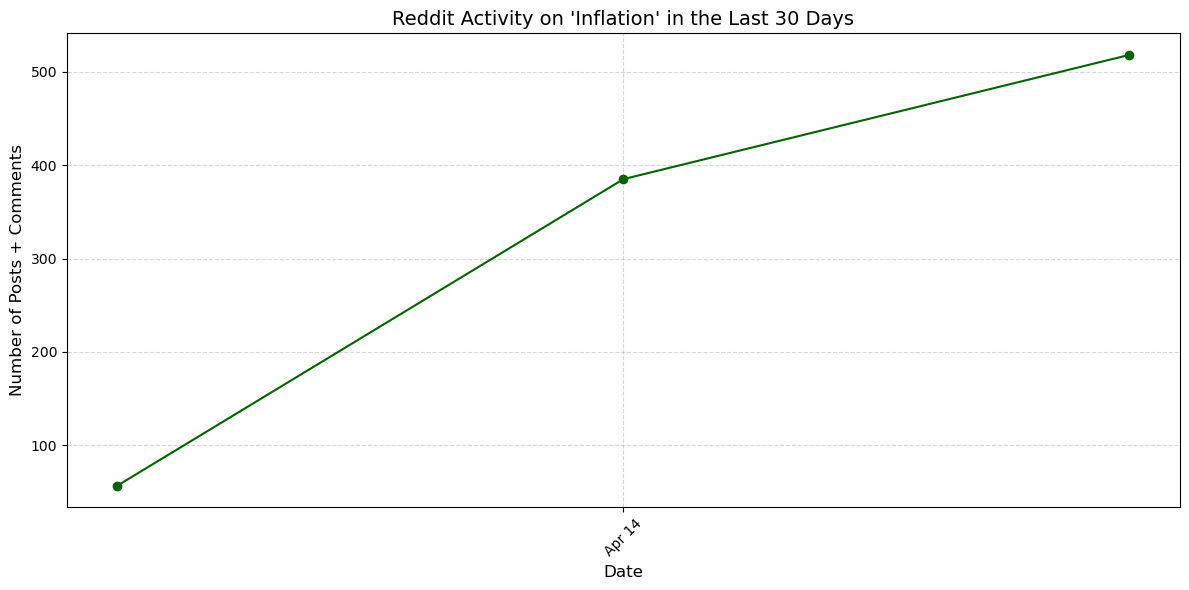

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the dataset
df = pd.read_json("reddit_inflation_cleaned.json")

# ✅ Use the correct column for date
df['Created'] = pd.to_datetime(df['Created'], errors='coerce')

# Filter for last 30 days
last_30_days = pd.Timestamp.today() - pd.Timedelta(days=30)
df_last30 = df[df['Created'] >= last_30_days]

# Extract just the date (drop time)
df_last30['DateOnly'] = df_last30['Created'].dt.date

# Count posts/comments by day
daily_counts = df_last30['DateOnly'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(daily_counts.index, daily_counts.values, marker='o', linestyle='-', color='darkgreen')

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.title("Reddit Activity on 'Inflation' in the Last 30 Days", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Posts + Comments", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


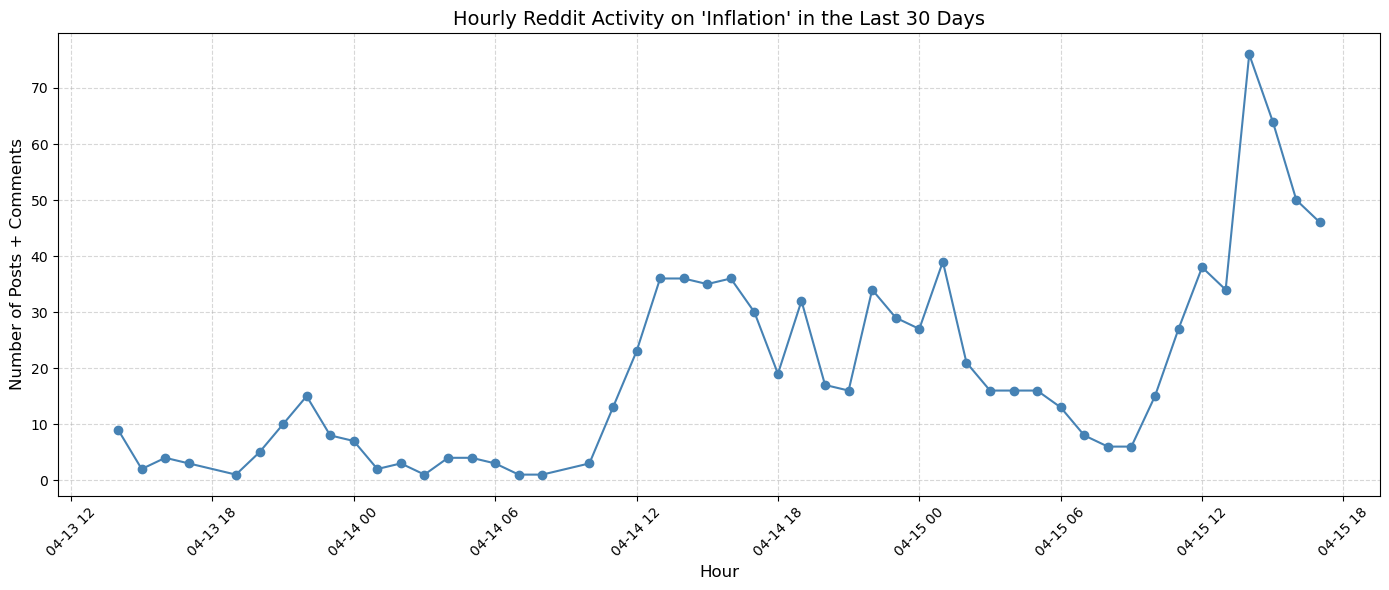

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset from JSON
df = pd.read_json("reddit_inflation_cleaned.json")

# ✅ Fix datetime parsing from the correct column
df['Created'] = pd.to_datetime(df['Created'], errors='coerce')

# Filter data for the last 30 days
last_30_days = pd.Timestamp.today() - pd.Timedelta(days=30)
df_30d = df[df['Created'] >= last_30_days].copy()

# ✅ Extract hour by flooring timestamp (using lowercase 'h' to avoid deprecation warning)
df_30d['Hour'] = df_30d['Created'].dt.floor('h')

# Count posts + comments per hour
hourly_counts = df_30d.groupby('Hour').size()

# 📊 Plotting the time series
plt.figure(figsize=(14, 6))
plt.plot(hourly_counts.index, hourly_counts.values, marker='o', linestyle='-', color='steelblue')

# Formatting
plt.title("Hourly Reddit Activity on 'Inflation' in the Last 30 Days", fontsize=14)
plt.xlabel("Hour", fontsize=12)
plt.ylabel("Number of Posts + Comments", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [65]:
import json
import re
from collections import Counter
from nltk.tokenize import TreebankWordTokenizer
from textblob import TextBlob

# Load Reddit data
with open("reddit_inflation_cleaned.json", "r", encoding="utf-8") as f:
    reddit_data = json.load(f)

# Combine text from all entries
all_text = " ".join([
    " ".join([
        entry.get("Title", ""),
        entry.get("Post Text", ""),
        entry.get("Comment", "")
    ]).lower() for entry in reddit_data
])

# Clean URLs and symbols
clean_text = re.sub(r"http\S+|www\S+", "", all_text)

# Tokenize and filter words
tokenizer = TreebankWordTokenizer()
tokens = tokenizer.tokenize(clean_text)
tokens = [word for word in tokens if word.isalpha()]

# Count frequencies
word_freq = Counter(tokens)

# Filter top N words to score
top_n = 1000
most_common_words = [word for word, _ in word_freq.most_common(top_n)]

# Classify based on sentiment polarity
positive_words = []
negative_words = []

for word in most_common_words:
    sentiment = TextBlob(word).sentiment.polarity
    if sentiment > 0:
        positive_words.append(word)
    elif sentiment < 0:
        negative_words.append(word)

# Save to separate files
with open("positive_words.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(positive_words))

with open("negative_words.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(negative_words))

print("✅ Generated 'positive_words.txt' and 'negative_words.txt' based on sentiment")


✅ Generated 'positive_words.txt' and 'negative_words.txt' based on sentiment


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


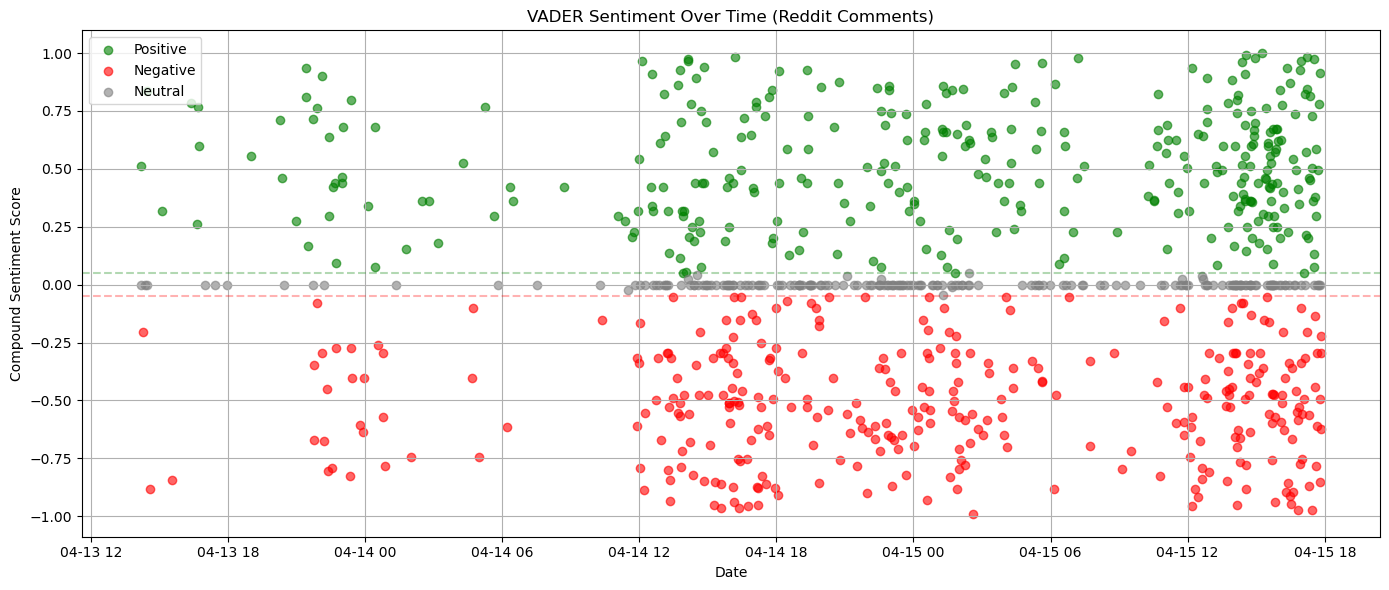


Sentiment distribution:
sentiment_label
negative    333
positive    333
neutral     194
Name: count, dtype: int64


In [35]:

import json
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Ensure VADER lexicon is available
nltk.download("vader_lexicon")

# Load Reddit-style JSON
INPUT_FILE = "reddit_inflation_cleaned.json"
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Extract and analyze comments
records = []
for entry in data:
    if entry.get("Type") == "Comment":
        text = entry.get("Comment", "")
        created = entry.get("Created")
        try:
            timestamp = pd.to_datetime(created)
        except:
            continue
        compound = sia.polarity_scores(text)["compound"]
        records.append({"datetime": timestamp, "compound": compound})

# Create DataFrame
df = pd.DataFrame(records)

# Categorize sentiment
df['sentiment_label'] = df['compound'].apply(
    lambda x: 'positive' if x >= 0.05 else 'negative' if x <= -0.05 else 'neutral'
)

# Plot with colored categories
plt.figure(figsize=(14, 6))
colors = {'positive': 'green', 'negative': 'red', 'neutral': 'gray'}

for label, color in colors.items():
    subset = df[df['sentiment_label'] == label]
    plt.scatter(subset['datetime'], subset['compound'], label=label.capitalize(), color=color, alpha=0.6)

plt.title("VADER Sentiment Over Time (Reddit Comments)")
plt.xlabel("Date")
plt.ylabel("Compound Sentiment Score")
plt.axhline(0.05, color='green', linestyle='--', alpha=0.3)
plt.axhline(-0.05, color='red', linestyle='--', alpha=0.3)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print sentiment breakdown
print("\nSentiment distribution:")
print(df['sentiment_label'].value_counts())


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



📊 Overall Sentiment Summary (Compound Scores):
Total Comments Analyzed: 860
Average Compound Sentiment: -0.000
Positive: 341
Negative: 336
Neutral : 183


C:\Users\shivani\AppData\Local\Temp\ipykernel_10592\3047300506.py:63: UserWarning: Glyph 128338 (\N{CLOCK FACE THREE OCLOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128338 (\N{CLOCK FACE THREE OCLOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


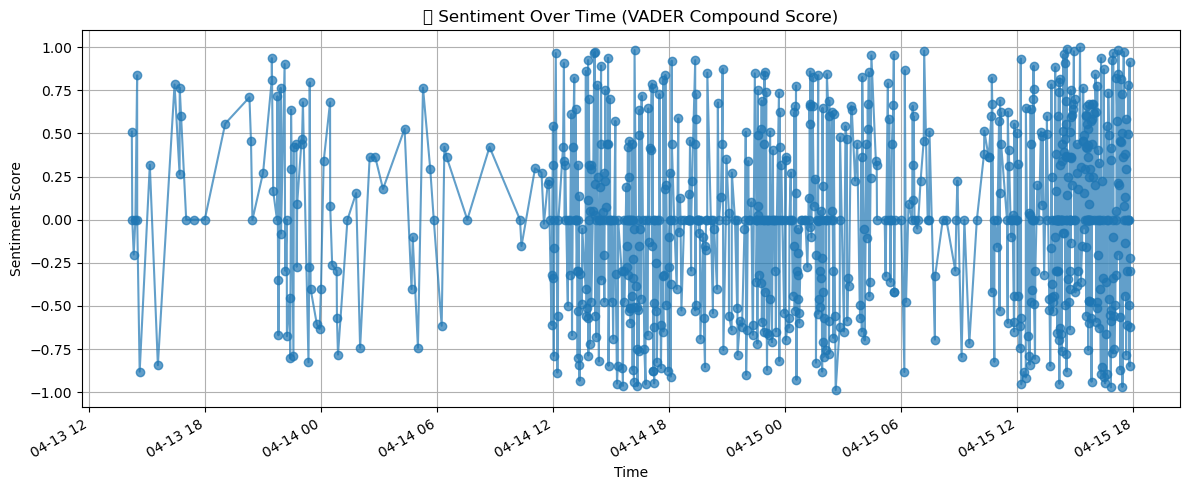


📌 Average Sentiment by Post:
1jzs8jf: -0.015
1jzqj6c: 0.206
1jzr5z9: 0.192
1jzwv2e: 0.584
1jztncq: 0.039
1jzsz5m: 0.168
1jztg5i: 0.372
1jzot6r: 0.034
1jz5e1g: -0.019
1jzq1y5: -0.410


In [53]:

import json
import re
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 🔧 Setup: Download required lexicon
nltk.download('vader_lexicon')

# 🧠 Initialize VADER
sia = SentimentIntensityAnalyzer()

# 📁 Input Reddit-style JSON file
INPUT_FILE = "reddit_inflation_cleaned.json"

# 📥 Load Reddit data
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    reddit_data = json.load(f)

# Containers for results
comment_sentiments = []
sentiment_by_post = defaultdict(list)
comment_timestamps = []

# 🔁 Analyze each comment
for entry in reddit_data:
    if entry.get("Type") == "Comment":
        comment = entry.get("Comment", "")
        score = sia.polarity_scores(comment)
        comment_sentiments.append(score["compound"])

        post_id = entry.get("Post ID", "unknown")
        sentiment_by_post[post_id].append(score["compound"])

        if "Created" in entry:
            try:
                dt = datetime.strptime(entry["Created"], "%Y-%m-%d %H:%M:%S")
                comment_timestamps.append((dt, score["compound"]))
            except:
                continue

# 📊 Summary
print("\n📊 Overall Sentiment Summary (Compound Scores):")
print(f"Total Comments Analyzed: {len(comment_sentiments)}")
print(f"Average Compound Sentiment: {sum(comment_sentiments)/len(comment_sentiments):.3f}")
print(f"Positive: {sum(1 for s in comment_sentiments if s > 0)}")
print(f"Negative: {sum(1 for s in comment_sentiments if s < 0)}")
print(f"Neutral : {sum(1 for s in comment_sentiments if s == 0)}")

# 📈 Sentiment over time
if comment_timestamps:
    comment_timestamps.sort()
    times, scores = zip(*comment_timestamps)
    plt.figure(figsize=(12, 5))
    plt.plot(times, scores, marker='o', linestyle='-', alpha=0.7)
    plt.title("🕒 Sentiment Over Time (VADER Compound Score)")
    plt.xlabel("Time")
    plt.ylabel("Sentiment Score")
    plt.gcf().autofmt_xdate()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 📌 Sentiment by post
print("\n📌 Average Sentiment by Post:")
for post_id, scores in list(sentiment_by_post.items())[:10]:
    avg = sum(scores) / len(scores)
    print(f"{post_id}: {avg:.3f}")


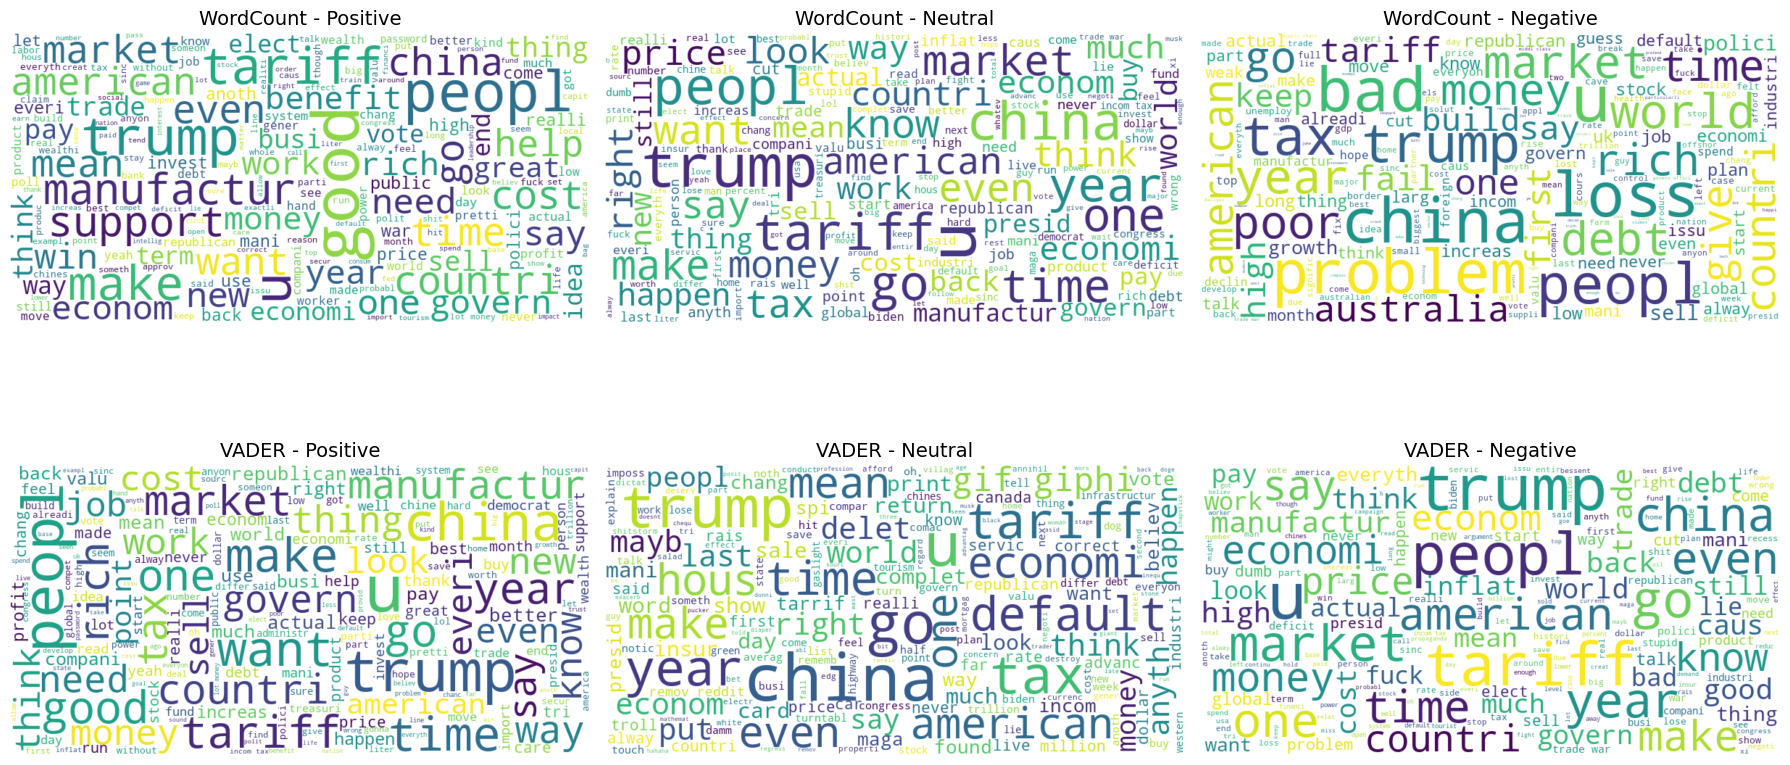

In [59]:
import json
import nltk
import string
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import TweetTokenizer
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Tools
tokenizer = TweetTokenizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english")) | set(string.punctuation)
sia = SentimentIntensityAnalyzer()

# Lexicons for Word Count method
pos_words = {"good", "great", "positive", "success", "support", "benefit", "help", "strong", "win"}
neg_words = {"bad", "poor", "fail", "negative", "problem", "struggle", "weak", "loss", "crisis"}

# Load your Reddit JSON
with open("reddit_inflation_cleaned.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Clean and classify
def clean_tokens(text):
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    return [stemmer.stem(t) for t in tokens if t not in stop_words and t.isalpha()]

def classify_count(score):
    return "Positive" if score > 0 else "Negative" if score < 0 else "Neutral"

def classify_vader(comp):
    return "Positive" if comp >= 0.05 else "Negative" if comp <= -0.05 else "Neutral"

# Store tokens
wordcloud_data = {
    "WordCount": {"Positive": [], "Neutral": [], "Negative": []},
    "VADER": {"Positive": [], "Neutral": [], "Negative": []}
}

for entry in data:
    if entry.get("Type") == "Comment":
        text = entry.get("Comment", "")
        tokens = clean_tokens(text)

        # Word Count sentiment
        score = sum(1 for t in tokens if t in pos_words) - sum(1 for t in tokens if t in neg_words)
        wordcloud_data["WordCount"][classify_count(score)].extend(tokens)

        # VADER sentiment
        comp = sia.polarity_scores(text)["compound"]
        wordcloud_data["VADER"][classify_vader(comp)].extend(tokens)

# Generate Word Cloud Grid
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
methods = ["WordCount", "VADER"]
sentiments = ["Positive", "Neutral", "Negative"]

for i, method in enumerate(methods):
    for j, sentiment in enumerate(sentiments):
        wc_text = " ".join(wordcloud_data[method][sentiment])
        wc = WordCloud(width=800, height=400, background_color='white', max_font_size=90).generate(wc_text)

        axs[i, j].imshow(wc, interpolation='bilinear')
        axs[i, j].axis("off")
        axs[i, j].set_title(f"{method} - {sentiment}", fontsize=14)

plt.tight_layout()
plt.show()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


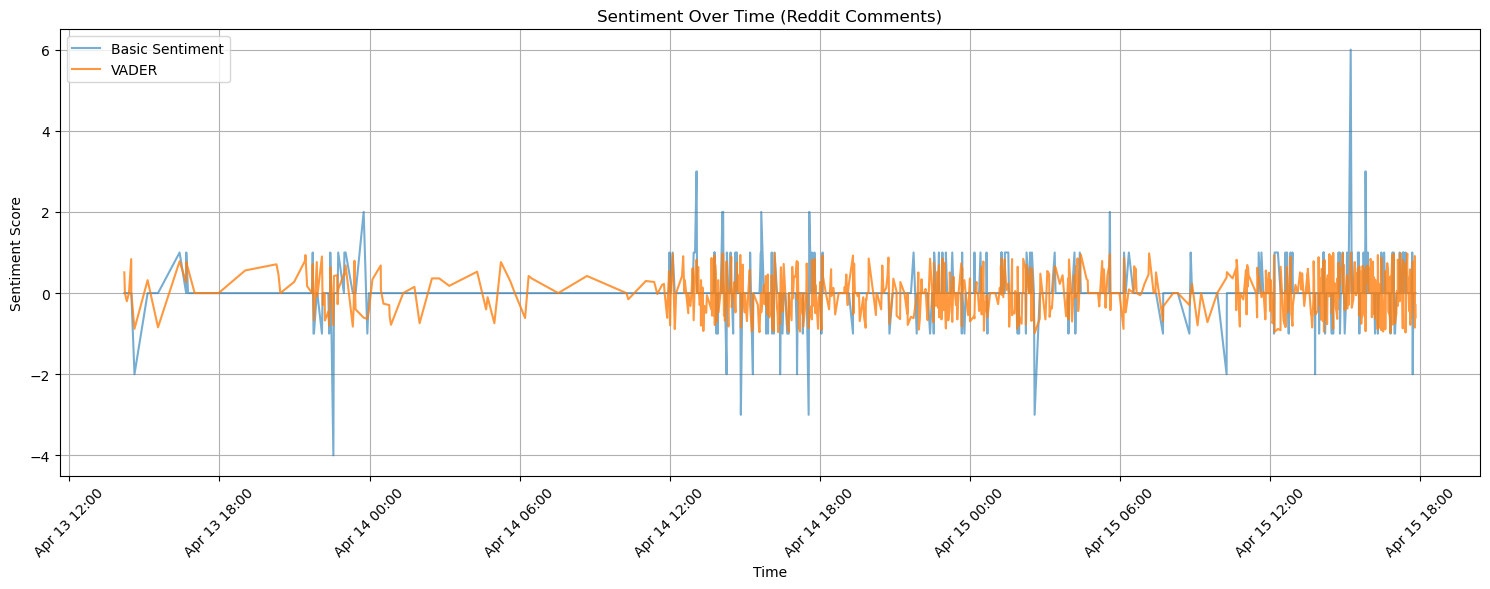

In [61]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string

# Setup
nltk.download("vader_lexicon")
nltk.download("stopwords")
sia = SentimentIntensityAnalyzer()
tokenizer = TweetTokenizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english")) | set(string.punctuation)

# Load Reddit data
with open("reddit_inflation_cleaned.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Opinion lexicons (simple)
pos_words = {"good", "great", "positive", "support", "strong", "win"}
neg_words = {"bad", "poor", "fail", "problem", "weak", "loss"}

# Clean and tokenize
def clean_tokens(text):
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    return [stemmer.stem(t) for t in tokens if t not in stop_words and t.isalpha()]

# DataFrame prep
records = []

for entry in data:
    if entry.get("Type") == "Comment":
        raw = entry.get("Comment", "")
        created = entry.get("Created", "")
        try:
            dt = datetime.strptime(created, "%Y-%m-%d %H:%M:%S")
        except:
            continue

        tokens = clean_tokens(raw)
        count_score = sum(1 for t in tokens if t in pos_words) - sum(1 for t in tokens if t in neg_words)
        vader_score = sia.polarity_scores(raw)["compound"]

        records.append({
            "datetime": dt,
            "count_sentiment": count_score,
            "vader_sentiment": vader_score
        })

# Convert to DataFrame
df = pd.DataFrame(records)
df = df.sort_values("datetime")

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(df["datetime"], df["count_sentiment"], label="Basic Sentiment", alpha=0.6)
plt.plot(df["datetime"], df["vader_sentiment"], label="VADER", alpha=0.8)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %d %H:%M"))
plt.xticks(rotation=45)
plt.title("Sentiment Over Time (Reddit Comments)")
plt.xlabel("Time")
plt.ylabel("Sentiment Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


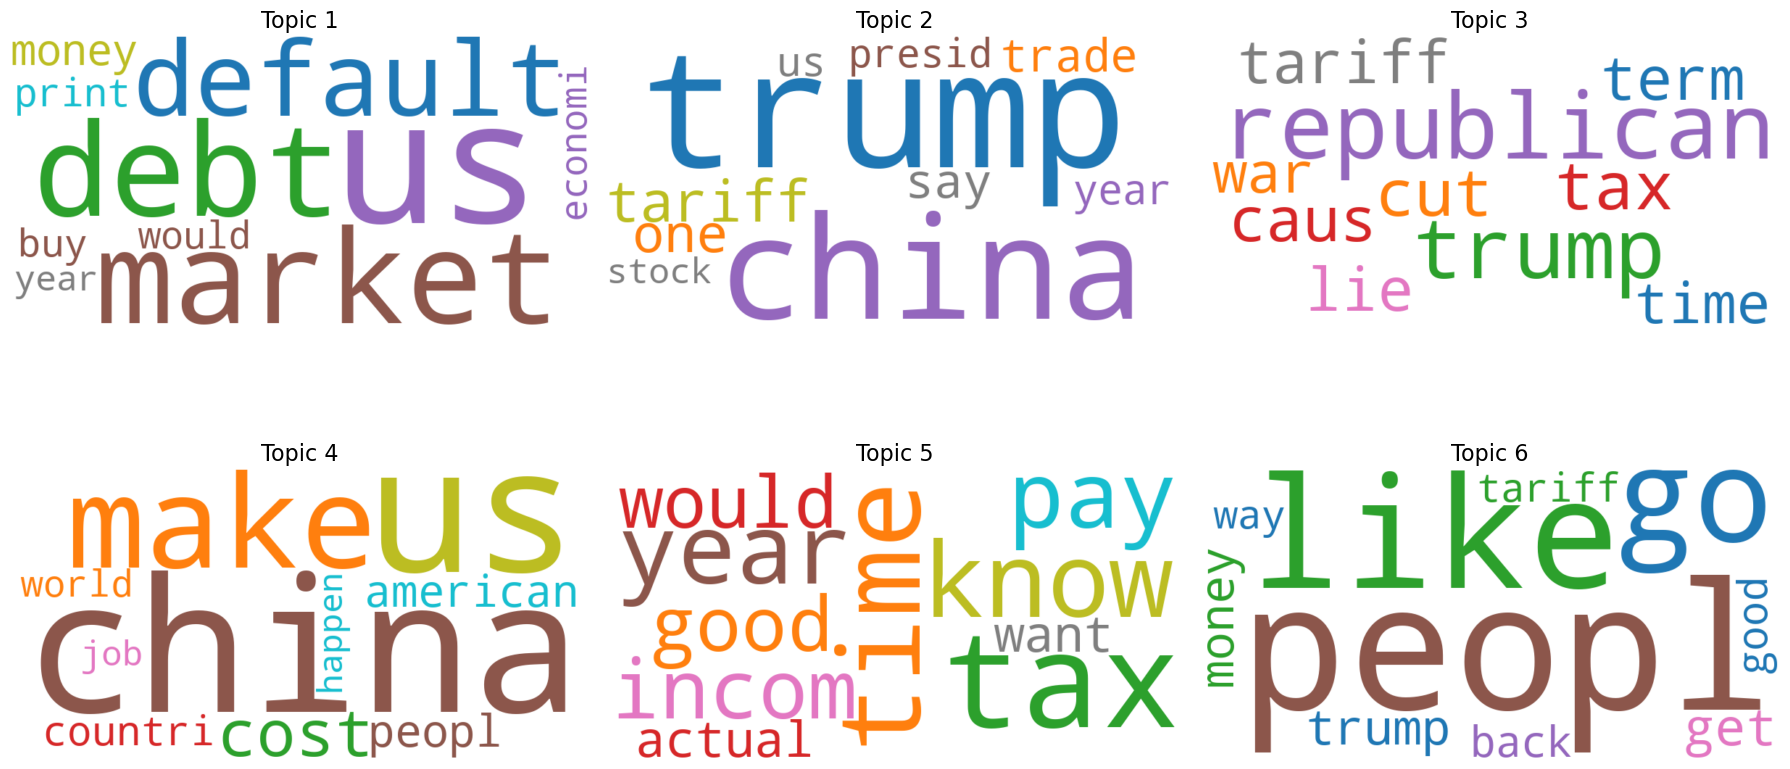

In [63]:
import json
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.tokenize import TweetTokenizer
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from gensim import corpora, models
import nltk

# 📥 Download stopwords
nltk.download("stopwords")

# 🔧 NLP Tools
tokenizer = TweetTokenizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english")) | set(string.punctuation)

# 🧼 Clean text function
def clean_text(text):
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    return [stemmer.stem(t) for t in tokens if t not in stop_words and t.isalpha()]

# 📁 Load your Reddit JSON file
with open("reddit_inflation_cleaned.json", "r", encoding="utf-8") as f:
    reddit_data = json.load(f)

# 🧹 Preprocess all comment texts
documents = []
for entry in reddit_data:
    if entry.get("Type") == "Comment":
        comment = entry.get("Comment", "")
        tokens = clean_text(comment)
        documents.append(tokens)

# 📚 Create dictionary and corpus for LDA
dictionary = corpora.Dictionary(documents)
dictionary.filter_extremes(no_below=5, no_above=0.5, keep_n=2000)
corpus = [dictionary.doc2bow(doc) for doc in documents]

# 🧠 Train LDA Model
num_topics = 6
lda_model = models.LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=10, random_state=42)

# ☁️ Generate and Save Word Cloud Grid
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
for i, topic in enumerate(lda_model.show_topics(num_topics=num_topics, num_words=10, formatted=False)):
    topic_words = dict(topic[1])
    wc = WordCloud(width=800, height=400, background_color='white', colormap='tab10')
    wc.generate_from_frequencies(topic_words)
    ax = axs[i // 3, i % 3]
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"Topic {i+1}", fontsize=16)
    ax.axis("off")

plt.tight_layout()
plt.savefig("reddit_lda_topics_wordcloud.png")
plt.show()
